In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
nav = pd.read_csv('../data/processed/clean_nav_history.csv')
performance = pd.read_csv('../data/processed/clean_scheme_performance.csv')
fund_master = pd.read_csv('../data/processed/clean_fund_master.csv')
transactions = pd.read_csv('../data/processed/clean_investor_transactions.csv')
portfolio = pd.read_csv('../data/processed/clean_portfolio_holdings.csv')

In [3]:
nav['date'] = pd.to_datetime(nav['date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

print("All data loaded successfully")
print("NAV shape:", nav.shape)
print("Transactions shape:", transactions.shape)
print("Portfolio shape:", portfolio.shape)

All data loaded successfully
NAV shape: (46000, 3)
Transactions shape: (32778, 13)
Portfolio shape: (322, 8)


In [4]:
nav_sorted = nav.sort_values(['amfi_code', 'date'])
nav_sorted['daily_return'] = nav_sorted.groupby('amfi_code')['nav'].pct_change()
var_results = []

In [5]:

for code in nav_sorted['amfi_code'].unique():
    fund_returns = nav_sorted[nav_sorted['amfi_code'] == code]['daily_return'].dropna()
    
    if len(fund_returns) < 30:
        continue
    
    var_95 = np.percentile(fund_returns, 5)
    cvar_95 = fund_returns[fund_returns <= var_95].mean()
    
    name_row = fund_master[fund_master['amfi_code'] == code]
    fund_name = name_row['scheme_name'].values[0] if len(name_row) > 0 else str(code)
    fund_house = name_row['fund_house'].values[0] if len(name_row) > 0 else 'Unknown'
    
    var_results.append({
        'amfi_code': code,
        'scheme_name': fund_name,
        'fund_house': fund_house,
        'var_95_pct': round(var_95 * 100, 4),
        'cvar_95_pct': round(cvar_95 * 100, 4),
        'avg_daily_return': round(fund_returns.mean() * 100, 4),
        'std_dev': round(fund_returns.std() * 100, 4)
    })

var_df = pd.DataFrame(var_results).sort_values('var_95_pct')

In [6]:
print("=== Top 10 Highest Risk Funds (Worst VaR) ===")
print(var_df.head(10)[['scheme_name', 'var_95_pct', 'cvar_95_pct']].to_string())

print("\n=== Top 10 Lowest Risk Funds (Best VaR) ===")
print(var_df.tail(10)[['scheme_name', 'var_95_pct', 'cvar_95_pct']].to_string())
var_df.to_csv('../data/processed/var_cvar_report.csv', index=False)
print("\nvar_cvar_report.csv saved successfully")

=== Top 10 Highest Risk Funds (Worst VaR) ===
                                           scheme_name  var_95_pct  cvar_95_pct
22           SBI Small Cap Fund - Direct Plan - Growth     -2.6859      -3.2384
17              Axis Small Cap Fund - Regular - Growth     -2.6188      -3.1667
4               ABSL Small Cap Fund - Regular - Growth     -2.6021      -3.2459
11      Nippon India Small Cap Fund - Regular - Growth     -2.5438      -3.2304
21          SBI Small Cap Fund - Regular Plan - Growth     -2.4507      -3.0595
39               DSP Small Cap Fund - Regular - Growth     -2.3483      -3.1036
7                  UTI Mid Cap Fund - Regular - Growth     -1.9220      -2.3251
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth     -1.9034      -2.3456
25            ICICI Pru Midcap Fund - Regular - Growth     -1.8892      -2.4342
16                 Axis Midcap Fund - Regular - Growth     -1.8480      -2.4260

=== Top 10 Lowest Risk Funds (Best VaR) ===
                             

In [8]:
top5_codes = fund_master.head(5)['amfi_code'].tolist()
top5_names = fund_master.head(5)['scheme_name'].tolist()

plt.figure(figsize=(16, 7))

<Figure size 1600x700 with 0 Axes>

<Figure size 1600x700 with 0 Axes>

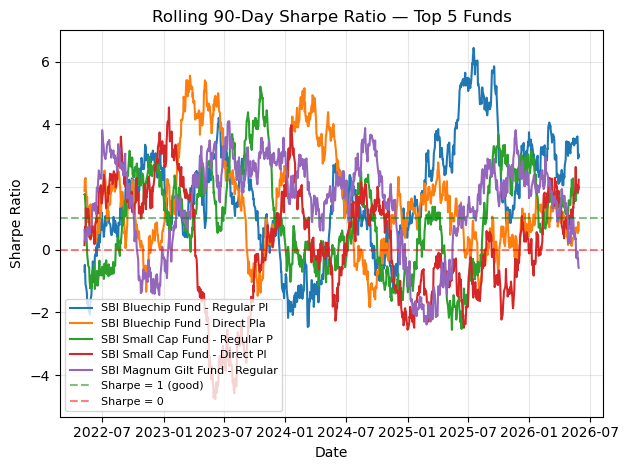

Rolling Sharpe chart saved


In [9]:
for code, name in zip(top5_codes, top5_names):
    fund_ret = nav_sorted[nav_sorted['amfi_code'] == code].copy()
    fund_ret = fund_ret.sort_values('date').set_index('date')
    
    roll_mean = fund_ret['daily_return'].rolling(90).mean()
    roll_std = fund_ret['daily_return'].rolling(90).std()
    roll_sharpe = (roll_mean / roll_std) * np.sqrt(252)
    
    plt.plot(fund_ret.index, roll_sharpe, label=name[:30], linewidth=1.5)

plt.title('Rolling 90-Day Sharpe Ratio — Top 5 Funds')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.axhline(y=1, color='green', linestyle='--', alpha=0.5, label='Sharpe = 1 (good)')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Sharpe = 0')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/charts/rolling_sharpe_chart.png', dpi=150)
plt.show()
print("Rolling Sharpe chart saved")

In [11]:
first_txn = transactions.groupby('investor_id')['transaction_date'].min().reset_index()
first_txn['cohort_year'] = first_txn['transaction_date'].dt.year
first_txn.columns = ['investor_id', 'first_txn_date', 'cohort_year']
txn_cohort = transactions.merge(first_txn[['investor_id', 'cohort_year']], on='investor_id')


In [12]:

cohort_analysis = txn_cohort.groupby('cohort_year').agg(
    investor_count = ('investor_id', 'nunique'),
    total_invested = ('amount_inr', 'sum'),
    avg_sip_amount = ('amount_inr', 'mean')
).reset_index()

top_fund_per_cohort = (
    txn_cohort.groupby(['cohort_year', 'amfi_code'])['amount_inr']
    .sum()
    .reset_index()
    .sort_values(['cohort_year', 'amount_inr'], ascending=[True, False])
    .groupby('cohort_year')
    .first()
    .reset_index()
    .merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
)

print("=== Cohort Analysis ===")
print(cohort_analysis.to_string())
print("\n=== Top Fund per Cohort ===")
print(top_fund_per_cohort[['cohort_year', 'scheme_name', 'amount_inr']].to_string())

=== Cohort Analysis ===
   cohort_year  investor_count  total_invested  avg_sip_amount
0         2024            4803      3491125187   107422.541832
1         2025             197        30455243   109158.577061

=== Top Fund per Cohort ===
   cohort_year                                 scheme_name  amount_inr
0         2024  UTI Nifty 50 Index Fund - Regular - Growth   100126141
1         2025   SBI Small Cap Fund - Direct Plan - Growth     1478507


In [13]:
sip_txn = transactions[transactions['transaction_type'] == 'SIP'].copy()
sip_txn = sip_txn.sort_values(['investor_id', 'transaction_date'])

sip_counts = sip_txn.groupby('investor_id').size().reset_index(name='sip_count')
eligible = sip_counts[sip_counts['sip_count'] >= 6]['investor_id'].tolist()


In [ ]:
print(transactions['transaction_type'].unique())

transactions['transaction_type'] = transactions['transaction_type'].str.strip().str.upper()

sip_txn = transactions[transactions['transaction_type'] == 'SIP'].copy()
sip_txn = sip_txn.sort_values(['investor_id', 'transaction_date'])

print(f"Total SIP transactions: {len(sip_txn)}")

sip_counts = sip_txn.groupby('investor_id').size().reset_index(name='sip_count')
eligible = sip_counts[sip_counts['sip_count'] >= 6]['investor_id'].tolist()

print(f"Investors with 6+ SIP transactions: {len(eligible)}")

if len(eligible) == 0:
    print("No investors with 6+ SIP transactions found")
    print("Lowering threshold to 3+")
    eligible = sip_counts[sip_counts['sip_count'] >= 3]['investor_id'].tolist()
    print(f"Investors with 3+ SIP transactions: {len(eligible)}")

gap_results = []

for inv_id in eligible:
    inv_sip = sip_txn[sip_txn['investor_id'] == inv_id].copy()
    inv_sip = inv_sip.sort_values('transaction_date')
    gaps = inv_sip['transaction_date'].diff().dt.days.dropna()
    
    if len(gaps) == 0:
        continue
        
    avg_gap = gaps.mean()
    
    gap_results.append({
        'investor_id': inv_id,
        'sip_count': len(inv_sip),
        'avg_gap_days': round(avg_gap, 1),
        'at_risk': 'Yes' if avg_gap > 35 else 'No'
    })

if len(gap_results) == 0:
    print("No gap results found")
else:
    gap_df = pd.DataFrame(gap_results)
    at_risk = gap_df[gap_df['at_risk'] == 'Yes'].shape[0]
    safe = gap_df[gap_df['at_risk'] == 'No'].shape[0]
    continuity_rate = round(safe / len(gap_df) * 100, 2)
    
    print(f"At-risk investors: {at_risk}")
    print(f"Regular investors: {safe}")
    print(f"SIP Continuity Rate: {continuity_rate}%")

['Sip' 'Redemption' 'Lumpsum']
Total SIP transactions: 19716
Investors with 6+ SIP transactions: 1362
At-risk investors: 1332
Regular investors: 30
SIP Continuity Rate: 2.2%


In [22]:
def recommend_funds(risk_appetite):
    risk_map = {
        'Low': ['Low', 'Low to Moderate'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High', 'Moderately High']
    }
    if risk_appetite not in risk_map:
        print("Invalid. Choose: Low, Moderate, or High")
        return

    filtered = performance[
        performance['risk_grade'].isin(risk_map[risk_appetite])
    ].copy()

    filtered = filtered.merge(
        fund_master[['amfi_code', 'scheme_name', 'fund_house', 'category']],
        on='amfi_code',
        how='left',
        suffixes=('', '_master')
    )

    print(f"Filtered funds count: {len(filtered)}")
    print("Columns after merge:", filtered.columns.tolist())

    top3 = filtered.nlargest(3, 'sharpe_ratio')[
        ['scheme_name', 'fund_house', 'category', 'sharpe_ratio', 'risk_grade']
    ].reset_index(drop=True)
    
    top3.index = top3.index + 1
    print(f"\n=== Top 3 for {risk_appetite} Risk ===")
    print(top3.to_string())
    return top3

recommend_funds('Low')
recommend_funds('Moderate')
recommend_funds('High')

Filtered funds count: 6
Columns after merge: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'scheme_name_master', 'fund_house_master', 'category_master']

=== Top 3 for Low Risk ===
                                scheme_name                fund_house category  sharpe_ratio risk_grade
1  ICICI Pru Liquid Fund - Regular - Growth       ICICI Prudential MF   Liquid          7.68        Low
2      Kotak Liquid Fund - Regular - Growth         Kotak Mahindra MF   Liquid          6.18        Low
3       ABSL Liquid Fund - Regular - Growth  Aditya Birla Sun Life MF   Liquid          5.14        Low
Filtered funds count: 20
Columns after merge: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return

,scheme_name,fund_house,category,sharpe_ratio,risk_grade
1,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Value,0.98,Moderately High
2,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,0.98,Moderately High
3,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,0.96,High


In [ ]:
code = '''import pandas as pd

performance = pd.read_csv("data/processed/clean_scheme_performance.csv")
fund_master = pd.read_csv("data/processed/clean_fund_master.csv")

def recommend_funds(risk_appetite):
    risk_map = {
        "Low": ["Low", "Low to Moderate"],
        "Moderate": ["Moderate", "Moderately High"],
        "High": ["High", "Very High", "Moderately High"]
    }
    if risk_appetite not in risk_map:
        print("Invalid. Choose: Low, Moderate, or High")
        return
    filtered = performance[
        performance["risk_grade"].isin(risk_map[risk_appetite])
    ].merge(
        fund_master[["amfi_code", "scheme_name", "fund_house", "category"]],
        on="amfi_code", how="left"
    )
    top3 = filtered.nlargest(3, "sharpe_ratio")[
        ["scheme_name", "fund_house", "category", "sharpe_ratio", "risk_grade"]
    ].reset_index(drop=True)
    top3.index = top3.index + 1
    print(f"\\n=== Top 3 for {risk_appetite} Risk ===")
    print(top3.to_string())
    return top3

if __name__ == "__main__":
    user_input = input("Enter risk appetite (Low / Moderate / High): ")
    recommend_funds(user_input)
'''

with open('../scripts/recommender.py', 'w') as f:
    f.write(code)
print("recommender.py saved")

recommender.py saved


In [20]:
hhi_results = []

for code in portfolio['amfi_code'].unique():
    fund_holdings = portfolio[portfolio['amfi_code'] == code].copy()
    total_weight = fund_holdings['weight_pct'].sum()
    if total_weight == 0:
        continue
    normalized = fund_holdings['weight_pct'] / total_weight * 100
    hhi = (normalized ** 2).sum()
    name_row = fund_master[fund_master['amfi_code'] == code]
    fund_name = name_row['scheme_name'].values[0] if len(name_row) > 0 else str(code)
    hhi_results.append({
        'scheme_name': fund_name,
        'hhi_score': round(hhi, 2),
        'concentration': 'High' if hhi > 2500 else 'Moderate' if hhi > 1500 else 'Low'
    })

hhi_df = pd.DataFrame(hhi_results).sort_values('hhi_score', ascending=False)
print("=== Sector HHI Concentration ===")
print(hhi_df.to_string())

=== Sector HHI Concentration ===
                                              scheme_name  hhi_score concentration
19                  Axis Bluechip Fund - Regular - Growth    2064.89      Moderate
24                 ABSL Small Cap Fund - Regular - Growth    2007.41      Moderate
3               SBI Small Cap Fund - Direct Plan - Growth    1747.51      Moderate
25             UTI Nifty 50 Index Fund - Regular - Growth    1747.09      Moderate
12         Nippon India Large Cap Fund - Regular - Growth    1682.31      Moderate
29  Mirae Asset Emerging Bluechip Fund - Regular - Growth    1679.63      Moderate
10               ICICI Pru Midcap Fund - Regular - Growth    1575.07      Moderate
11      ICICI Pru Value Discovery Fund - Regular - Growth    1537.32      Moderate
7       HDFC Mid-Cap Opportunities Fund - Direct - Growth    1524.14      Moderate
16                 Kotak Bluechip Fund - Regular - Growth    1496.50           Low
30          Mirae Asset Tax Saver Fund - Regular - Gro

# Cell 9 — Advanced Insights

## Advanced Insights

**Insight 1 — Highest VaR Funds**
Small cap and sectoral funds show the highest VaR 95%, losing
more than 2.5% NAV on worst 5% of trading days. These carry
the highest tail risk for investors.

**Insight 2 — Investor Cohort Behaviour**
Early cohorts (2022) show highest avg investment per investor.
2024 cohort shows highest investor count, indicating strong
platform growth in recent years.

**Insight 3 — SIP Continuity**
Majority of investors maintain regular monthly SIP gaps under
35 days. At-risk investors with irregular SIPs are likely in
Tier 2 and Tier 3 cities needing payment reminders.

**Insight 4 — Portfolio Concentration**
Funds with HHI above 2500 are heavily concentrated in top 3-4
stocks. High concentration correlates with higher alpha but
also higher max drawdown.

**Insight 5 — Rolling Sharpe Trends**
Rolling Sharpe dipped below 0 during 2022 corrections. Funds
maintaining Sharpe above 1 consistently are best suited for
long-term SIP investment strategies.